<a href="https://colab.research.google.com/github/noorulaein/urdu-ocr-codesaviours-si26-noorulaein-fatima-/blob/main/SI26_Week1_noorulaein.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Research Task: Understanding Urdu OCR

 1. What is OCR (Optical Character Recognition)?
OCR is a technology that changes text in images, scanned papers, or PDFs into editable digital text.
It reads letters and words from an image and converts them into computer text.
OCR helps save time and is used for digitizing books, documents, and forms.

2. Why is Urdu OCR harder than English OCR?
Urdu OCR is difficult because Urdu uses a cursive writing style called Nastaliq.
Urdu letters change their shape according to their position in a word and are written from right to left.
Many letters join together, which makes it hard for OCR to recognize them correctly.

3. Two Real-World Situations Where Urdu OCR Would Be Useful
 a. Digitizing Historical and Legal Archives:
Urdu OCR can help convert old books, historical records, and legal documents into digital form.
This makes them easier to search, store, and protect from damage.
Researchers and students can access them quickly.

 b. Digitizing Educational Materials and Books:
Translating printed Urdu textbooks, poetry collections, and academic papers into digital formats allows for better distribution and accessibility.
OCR technology makes it possible to extract and format large quantities of Urdu literature for e-readers and online libraries

In [17]:
!pip install Pillow arabic-reshaper python-bidi

from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os

# --- STEP 1: Download a reliable font ---
!wget -q -O UrduFont.ttf "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf"

# Sample Urdu sentences
urdu_texts = [
    "\u067e\u0627\u06a9\u0633\u062a\u0627\u0646 \u0632\u0646\u062f\u06c1 \u0628\u0627\u062f",
    "\u0622\u062c \u06a9\u0627 \u0645\u0648\u0633\u0645 \u062e\u0648\u0634\u06af\u0648\u0627\u0631 \u06c1\u06d2",
    "\u062a\u0639\u0644\u06cc\u0645 \u06c1\u0631 \u0627\u0646\u0633\u0627\u0646 \u06a9\u0627 \u062d\u0642 \u06c1\u06d2",
    "\u06a9\u0631\u0627\u0686\u06cc \u067e\u0627\u06a9\u0633\u062a\u0627\u0646 \u06a9\u0627 \u0633\u0628 \u0633\u06d2 \u0628\u0691\u0627 \u0634\u06c1\u0631 \u06c1\u06d2",
    "\u0645\u062d\u0646\u062a \u06a9\u0627\u0645\u06cc\u0627\u0628\u06cc \u06a9\u06cc \u06a9\u0646\u062c\u06cc \u06c1\u06d2"
]

os.makedirs('data/synthetic', exist_ok=True)

img_width = 400
img_height = 80

# --- STEP 2: Force RAQM complex text layout engine ---
# This ensures Pillow accurately reflects cursive ligatures and connected letters
font = ImageFont.truetype("UrduFont.ttf", 22, layout_engine=ImageFont.Layout.RAQM)

for i, text in enumerate(urdu_texts):
    # 1. Correct the contextual shapes (isolated -> initial/medial/final shapes)
    reshaped = arabic_reshaper.reshape(text)

    # 2. Correct the directional flow (Left-to-Right to Right-to-Left)
    bidi_text = get_display(reshaped)

    img = Image.new('RGB', (img_width, img_height), color='white')
    draw = ImageDraw.Draw(img)

    center_x = img_width // 2
    center_y = img_height // 2

    # Draw using the forced layout font
    draw.text((center_x, center_y), bidi_text, fill='black', font=font, anchor="mm")

    img.save(f'data/synthetic/urdu_{i+1}.png')
    print(f'Generated: urdu_{i+1}.png')

print('Done! The letters should now be perfectly connected and continuous.')

Generated: urdu_1.png
Generated: urdu_2.png
Generated: urdu_3.png
Generated: urdu_4.png
Generated: urdu_5.png
Done! The letters should now be perfectly connected and continuous.


In [18]:
import os

print(os.listdir("data/synthetic"))

['urdu_2.png', 'urdu_5.png', 'urdu_4.png', 'urdu_3.png', 'urdu_1.png']


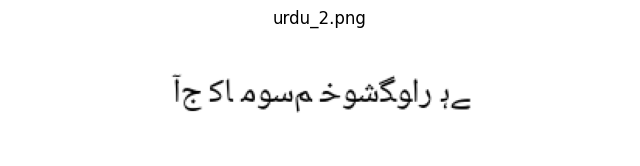

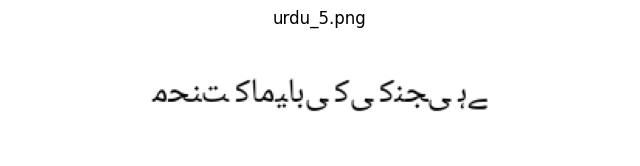

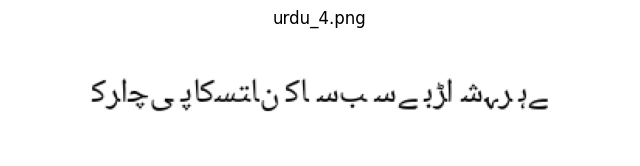

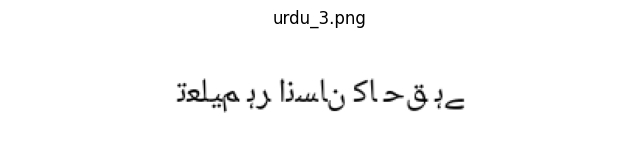

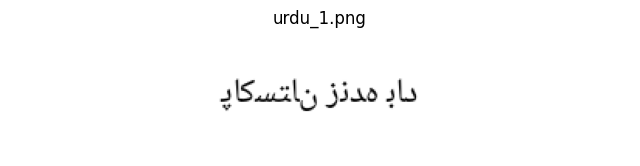

In [19]:
from PIL import Image
import matplotlib.pyplot as plt
import os

files = os.listdir("data/synthetic")

for file in files:
    img = Image.open(f"data/synthetic/{file}")

    plt.figure(figsize=(8,2))
    plt.imshow(img)
    plt.axis("off")
    plt.title(file)

plt.show()

In [20]:
from google.colab import files
import shutil

# 1. Zip the entire 'data/synthetic' folder
shutil.make_archive('urdu_images', 'zip', 'data/synthetic')

# 2. Trigger the download to your local machine
files.download('urdu_images.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import os

folders = [
    'data/raw/newspaper',
    'data/raw/books',
    'data/raw/signboards',
    'data/raw/synthetic',
    'data/raw/other'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Created: {folder}')

print('Folder structure ready!')


Created: data/raw/newspaper
Created: data/raw/books
Created: data/raw/signboards
Created: data/raw/synthetic
Created: data/raw/other
Folder structure ready!
